# 📰 Final Project - Pemrosesan Bahasa Alami
## Scraping Berita Banjir | Sentiment Analysis Banjir Bandang & Banjir Biasa
---
> **Bagian:** Term Frequency-Inverse Document Frequency - TF-IDF (Vectorization)  
> **Deskripsi:** Representasi teks berita banjir menggunakan metode pembobotan TF-IDF untuk membedakan karakteristik kata antara banjir biasa dan banjir bandang

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# Load data
df = pd.read_csv('data_banjir_master_lemmatized.csv', usecols=['After_lemma', 'Sentimen'])
df = df.dropna(subset=['After_lemma'])
df['Sentimen'] = df['Sentimen'].str.strip().str.lower()

# Pisah per kategori
corpus_biasa   = df[df['Sentimen'] == 'banjir']['After_lemma'].astype(str).tolist()
corpus_bandang = df[df['Sentimen'] == 'bandang']['After_lemma'].astype(str).tolist()
corpus_all     = corpus_biasa + corpus_bandang
labels_all     = ['Banjir Biasa'] * len(corpus_biasa) + ['Banjir Bandang'] * len(corpus_bandang)

print(f"Jumlah dokumen Banjir Biasa  : {len(corpus_biasa)}")
print(f"Jumlah dokumen Banjir Bandang: {len(corpus_bandang)}")

Jumlah dokumen Banjir Biasa  : 683
Jumlah dokumen Banjir Bandang: 971


In [7]:
# Fit TF-IDF
vectorizer = TfidfVectorizer(
    max_features=500,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

tfidf_matrix = vectorizer.fit_transform(corpus_all)
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_tfidf['kategori'] = labels_all

print(f"Shape matrix TF-IDF: {tfidf_matrix.shape}")

Shape matrix TF-IDF: (1654, 500)


In [8]:
# Top TF-IDF per kategori
def get_top_tfidf(df_tfidf, kategori, top_n=20):
    df_cat = df_tfidf[df_tfidf['kategori'] == kategori].drop(columns='kategori')
    mean_score = df_cat.mean(axis=0).sort_values(ascending=False)
    return mean_score.head(top_n).reset_index().rename(columns={'index': 'Kata', 0: 'TF-IDF Score'})

top_biasa   = get_top_tfidf(df_tfidf, 'Banjir Biasa', top_n=20)
top_bandang = get_top_tfidf(df_tfidf, 'Banjir Bandang', top_n=20)

top_biasa.columns   = ['Kata', 'TF-IDF Score']
top_bandang.columns = ['Kata', 'TF-IDF Score']

print("\n=== TOP 20 KATA - BANJIR BIASA ===")
display(top_biasa)
print("\n=== TOP 20 KATA - BANJIR BANDANG ===")
display(top_bandang)


=== TOP 20 KATA - BANJIR BIASA ===


,Kata,TF-IDF Score
0,banjir,0.128760
1,air,0.116469
2,jalan,0.092837
3,warga,0.088698
4,genang,0.077997
5,hujan,0.073861
6,rumah,0.071621
7,rendam,0.069410
8,tingi,0.060973
9,jadi,0.056372



=== TOP 20 KATA - BANJIR BANDANG ===


,Kata,TF-IDF Score
0,banjir,0.067598
1,bencana,0.065303
2,korban,0.061039
3,orang,0.057131
4,aceh,0.055375
5,kabupaten,0.048833
6,bandang,0.048196
7,wilayah,0.047645
8,banjir bandang,0.047618
9,sumatera,0.047134


/tmp/ipykernel_5993/1118662762.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_biasa, x='TF-IDF Score', y='Kata', palette='Blues_r', ax=axes[0])
/tmp/ipykernel_5993/1118662762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bandang, x='TF-IDF Score', y='Kata', palette='Oranges_r', ax=axes[1])


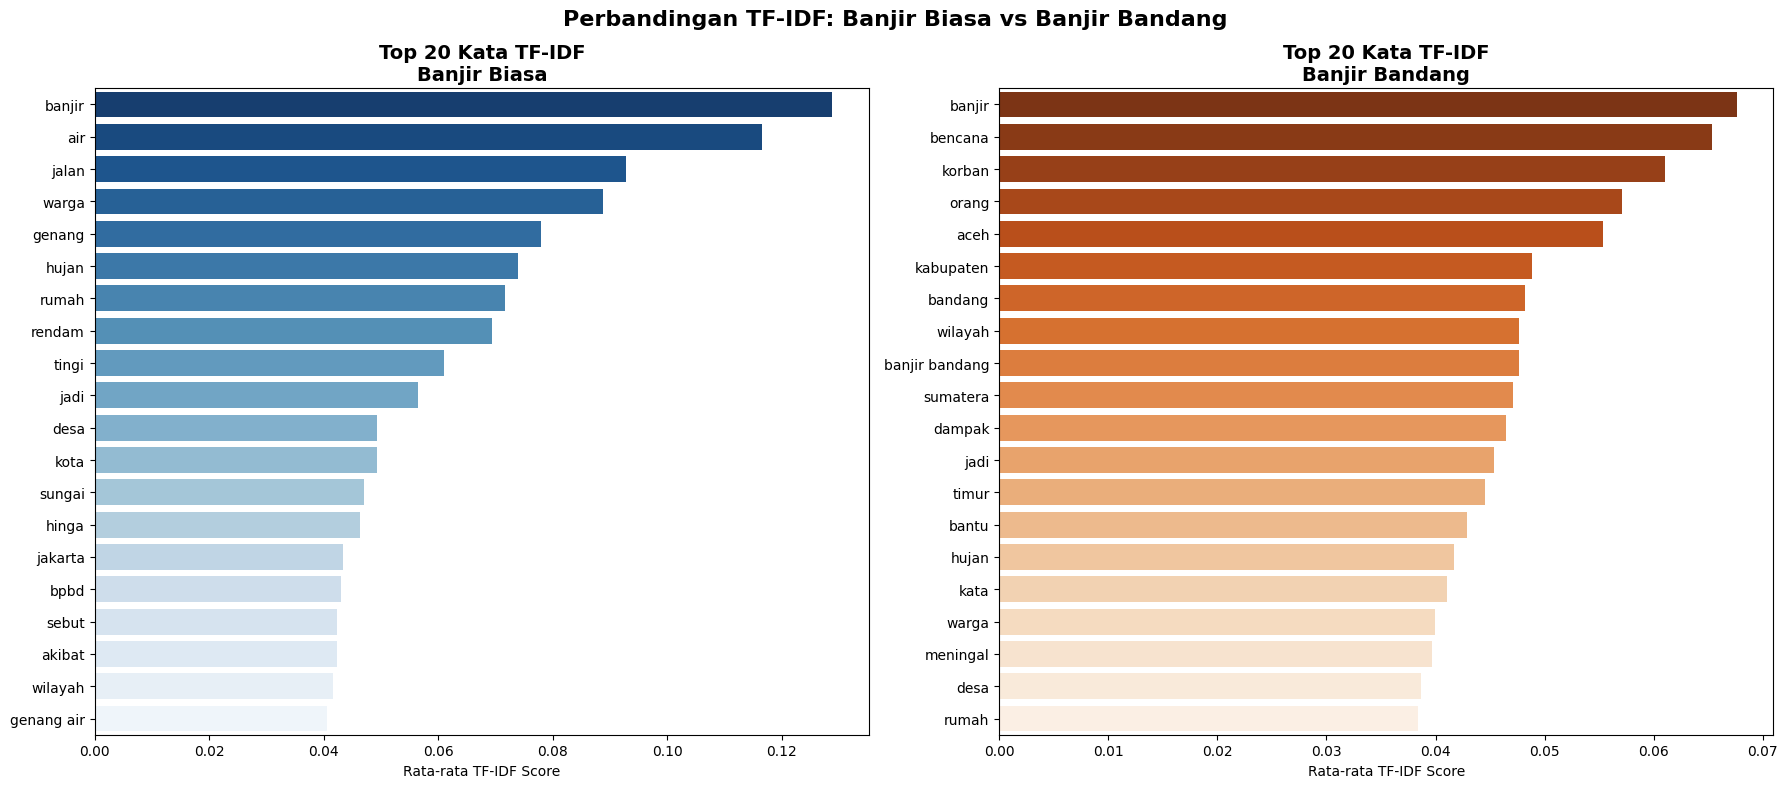

In [9]:
# Visualisasi 1: Bar Chart perbandingan
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(data=top_biasa, x='TF-IDF Score', y='Kata', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 20 Kata TF-IDF\nBanjir Biasa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rata-rata TF-IDF Score')
axes[0].set_ylabel('')

sns.barplot(data=top_bandang, x='TF-IDF Score', y='Kata', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 20 Kata TF-IDF\nBanjir Bandang', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rata-rata TF-IDF Score')
axes[1].set_ylabel('')

plt.suptitle('Perbandingan TF-IDF: Banjir Biasa vs Banjir Bandang', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

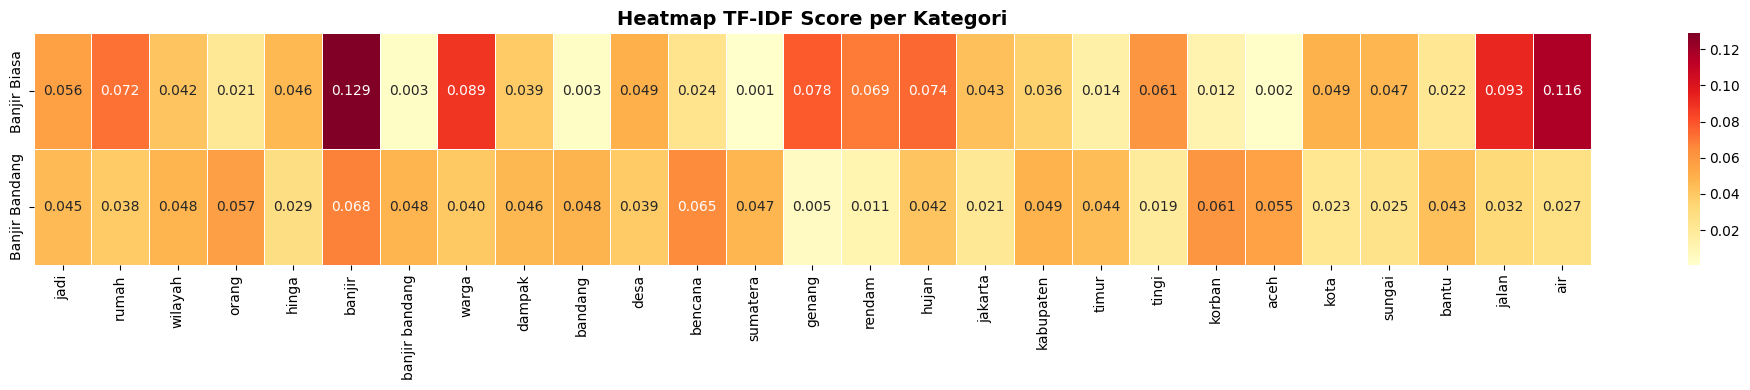

In [10]:
# Visualisasi 2: Heatmap Top 15 kata
top15_biasa   = top_biasa.head(15).set_index('Kata')
top15_bandang = top_bandang.head(15).set_index('Kata')

all_words = list(set(top15_biasa.index.tolist() + top15_bandang.index.tolist()))

heatmap_data = pd.DataFrame({
    'Banjir Biasa'  : df_tfidf[df_tfidf['kategori'] == 'Banjir Biasa'][all_words].mean(),
    'Banjir Bandang': df_tfidf[df_tfidf['kategori'] == 'Banjir Bandang'][all_words].mean()
}).T

plt.figure(figsize=(20, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap TF-IDF Score per Kategori', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Simpan hasil
top_biasa['kategori']   = 'Banjir Biasa'
top_bandang['kategori'] = 'Banjir Bandang'

df_top_tfidf = pd.concat([top_biasa, top_bandang], ignore_index=True)
df_top_tfidf.to_csv('tfidf_top_kata.csv', index=False)
df_tfidf.to_csv('tfidf_matrix.csv', index=False)

print("✅ File 'tfidf_top_kata.csv' dan 'tfidf_matrix.csv' berhasil disimpan!")

✅ File 'tfidf_top_kata.csv' dan 'tfidf_matrix.csv' berhasil disimpan!
